# Present Results

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

import scipy.stats as stats
from matplotlib.pyplot import figure
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split

from sklearn.svm import LinearSVC

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA



from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score, roc_auc_score, roc_curve, classification_report, confusion_matrix


## Load Dataset

In [10]:
df_clean = pd.read_csv('intermediateData/cleanData.csv', index_col=0)
print("Shape:", df_clean.shape)
df_clean.head(1)

Shape: (905, 549)


,Timestamp,What is your age group?,What is your gender?,What is your sexuality?,Where do you live?,What is your current occupation?,"Are you generally introverted, extroverted in real life?",How often do you browse r/Twice?,How did you discover r/Twice?,"Other than Twice, what other k-pop groups do you listen to?",...,x_ss_artm_ovrl_cbk_n_bit_4,x_xs_artm_mpp_year,x_xs_artm_mpp_memb_n,x_ss_artm_mpp_memb_n_bit_0,x_ss_artm_mpp_memb_n_bit_1,x_ss_artm_mpp_memb_n_bit_2,x_ss_artm_mpp_memb_n_bit_3,x_xs_misc_pop_group_num,x_xs_misc_cvd_group_num,x_xs_misc_wop_group_num
0,12/26/2021 3:47:53,20-25,Female,Gay/Lesbian,North America,Unemployed,It depends who I'm around,A few times a month,Reddit Browsing,"BTS, EXO, ITZY, BlackPink, Red Velvet, SNSD, S...",...,1,3.0,8.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [11]:
x_columns = [col for col in df_clean.columns if col.startswith('x_')] 
y_columns = [col for col in df_clean.columns if col.startswith('y_')]
print("Feature_Count:", len(x_columns))
print(y_columns)

Feature_Count: 474
['y_album_buying']


In [31]:
df_x_identity = df_clean[[
    "x_xs_demo_gen_group_num",
    "x_ss_demo_role_prof_e",
    "x_xs_demo_regi_group_num",
    "x_xs_demo_heal_group_num",
    "x_ss_demo_vert_middle",
    "x_ss_demo_vert_intro",
    "x_ss_demo_vert_depends",
    "x_ss_demo_vert_extro",
    "x_ss_demo_role_stud_u",
    "x_ss_demo_role_prof_u",
    "x_ss_demo_role_stud_e",
    "x_ss_demo_sex_other",
    "x_mm_demo_regi_america_n",
    "x_mm_demo_regi_america_c_s",  # Repeate
    "x_mm_demo_regi_other_other",
    "x_mm_demo_ag_000_014",
    "x_xs_beha_evt_live",
    "x_xs_beha_mf_group_num",
    "x_xs_beha_evt_tour", # Repeate
    "x_xs_beha_evt_kcon",
    "x_mm_altm_jglt_dy6",
]].copy()

# Identity: Gender, Geographic Region, Healed by Kpop, Extroversion Level, Job Status, Student Status, Biological Sex, Events Attended, If you listen to Day 6, Months Following Group

df_x_opinion = df_clean[[
    "x_xs_comp_dis_sent",
    "x_xs_comp_west_sent",
    "x_xs_artm_mpp_memb_n",
    "x_ss_artm_mpp_memb_n_bit_0",
    "x_ll_memb_soe_Dahyun_mnh",
    "x_ll_memb_soe_Jihyo_btd",
    "x_ll_memb_soe_Jihyo_loa",
    "x_ll_memb_soe_Sana_loa",
    "x_ll_memb_soe_Tzuyu_none",
    "x_ll_memb_soe_Jihyo_pds",
    "x_ll_memb_soe_Nayeon_sgl",
    "x_ll_memb_soe_Dahyun_knk", # Repeate
    "x_ll_memb_soe_Chaeyoung_csm",
    "x_ll_memb_soe_Sana_yoy",
    "x_ll_memb_soe_Dahyun_loa",    
]].copy()

# What you would do if the group dispanded, opinion on groups western activities, member featured in your favorite melody project, different members stand out era



In [32]:
scaler = MinMaxScaler()
df_x_identity_scaled = pd.DataFrame(scaler.fit_transform(df_x_identity), columns=df_x_identity.columns)
pca = PCA(n_components=1, random_state=42)
x_identity_pca_1 = pca.fit_transform(df_x_identity_scaled)
df_clean["x_xs_identity_pca_1"]= x_identity_pca_1
df_clean["x_xs_identity_pca_1"].value_counts().head(10)

x_xs_identity_pca_1
 0.887133    9
 0.881717    7
 0.897965    7
-0.174276    5
-0.936502    4
 0.908796    4
 0.108659    4
 0.904713    4
 0.563644    3
 0.110701    3
Name: count, dtype: int64

In [33]:
scaler = MinMaxScaler()
df_x_opinion_scaled = pd.DataFrame(scaler.fit_transform(df_x_opinion), columns=df_x_opinion.columns)
pca = PCA(n_components=1, random_state=42)
x_opinion_pca_1 = pca.fit_transform(df_x_opinion_scaled)
df_clean["x_xs_opinion_pca_1"]= x_opinion_pca_1
df_clean["x_xs_opinion_pca_1"].value_counts().head(10)




x_xs_opinion_pca_1
 0.744629    63
 0.739289    57
 0.733948    48
-0.219680    27
-0.639085    25
-0.644426    21
-0.300262    19
-0.294922    19
-0.155120    19
-0.160460    17
Name: count, dtype: int64

In [ ]:
fig = px.scatter(df_clean,
                 x="x_xs_identity_pca_1",
                 y="x_xs_opinion_pca_1",
                 color="y_album_buying" ,# "Status", #Status cluster
                 color_discrete_sequence=px.colors.qualitative.Safe,
                 #color_discrete_sequence=['#FF0000', '#0000FF', '#00FF00', '#FFD700', '#800080'],  # Red, Blue, Green, Gold, Purple
                 #hover_data=['university_name']
                )

fig.update_layout(width=800, height=600)
fig.show()



In [35]:
# Feature "x_xs_identity_pca_1" and "x_xs_opinion_pca_1" into these bins and get the rate of "y_album_buying" for each bin combination?

# x_xs_identity_pca_1_bins = [-1.5, -1.1, -0.75, -0.32, 0, 0.35, 0.7, 1]

# x_xs_opinion_pca_1_bins = [-0.8, -0.5, -0.32, 0.2, 1]

In [36]:
import pandas as pd
import numpy as np

# Assuming df is your DataFrame with the necessary columns
# Define the bins
x_xs_identity_pca_1_bins = [-1.5, -1.1, -0.75, -0.32, 0, 0.35, 0.7, 1]
x_xs_opinion_pca_1_bins = [-0.8, -0.5, -0.32, 0.2, 1]

# Create bin labels for better readability
identity_labels = [f'{x_xs_identity_pca_1_bins[i]} to {x_xs_identity_pca_1_bins[i+1]}' 
                  for i in range(len(x_xs_identity_pca_1_bins)-1)]
opinion_labels = [f'{x_xs_opinion_pca_1_bins[i]} to {x_xs_opinion_pca_1_bins[i+1]}' 
                 for i in range(len(x_xs_opinion_pca_1_bins)-1)]

# Bin the data
df_clean['identity_bin'] = pd.cut(df_clean['x_xs_identity_pca_1'], bins=x_xs_identity_pca_1_bins, 
                           labels=identity_labels, include_lowest=True)
df_clean['opinion_bin'] = pd.cut(df_clean['x_xs_opinion_pca_1'], bins=x_xs_opinion_pca_1_bins, 
                          labels=opinion_labels, include_lowest=True)

# Group by both bin combinations and calculate the buying rate
result = df_clean.groupby(['identity_bin', 'opinion_bin'])['y_album_buying'].agg(
    count='count',
    buy_rate='mean'
).reset_index()

# Sort the results if needed
result = result.sort_values(['identity_bin', 'opinion_bin'])

# Display the results
print(result)

      identity_bin    opinion_bin  count  buy_rate
0     -1.5 to -1.1   -0.8 to -0.5      8  0.250000
1     -1.5 to -1.1  -0.5 to -0.32      5  0.200000
2     -1.5 to -1.1   -0.32 to 0.2     19  0.526316
3     -1.5 to -1.1       0.2 to 1     12  0.416667
4    -1.1 to -0.75   -0.8 to -0.5     15  0.200000
5    -1.1 to -0.75  -0.5 to -0.32     11  0.454545
6    -1.1 to -0.75   -0.32 to 0.2     31  0.612903
7    -1.1 to -0.75       0.2 to 1     32  0.531250
8   -0.75 to -0.32   -0.8 to -0.5     26  0.346154
9   -0.75 to -0.32  -0.5 to -0.32     23  0.434783
10  -0.75 to -0.32   -0.32 to 0.2     45  0.533333
11  -0.75 to -0.32       0.2 to 1     49  0.530612
12      -0.32 to 0   -0.8 to -0.5     29  0.275862
13      -0.32 to 0  -0.5 to -0.32     26  0.538462
14      -0.32 to 0   -0.32 to 0.2     51  0.549020
15      -0.32 to 0       0.2 to 1     52  0.423077
16       0 to 0.35   -0.8 to -0.5     37  0.405405
17       0 to 0.35  -0.5 to -0.32     21  0.523810
18       0 to 0.35   -0.32 to 0

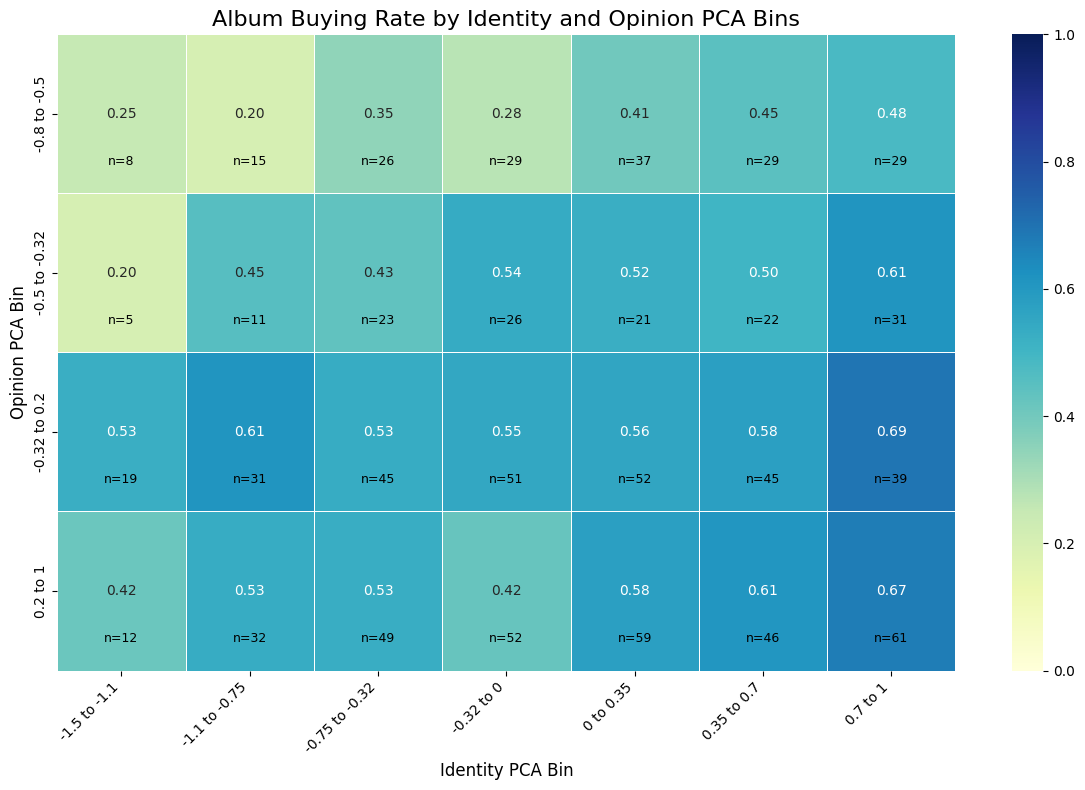

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create a pivot table for the heatmap
pivot_table = result.pivot(index='opinion_bin', 
                           columns='identity_bin', 
                           values='buy_rate')

# Set up the matplotlib figure
plt.figure(figsize=(12, 8))

# Create the heatmap
heatmap = sns.heatmap(pivot_table, 
                      annot=True,  # Show values in cells
                      fmt='.2f',   # Format values to 2 decimal places
                      cmap='YlGnBu',  # Color map (blues)
                      linewidths=0.5,
                      vmin=0, 
                      vmax=1)  # Set range from 0 to 1 for rate

# Add a count annotation to each cell
for i, opinion in enumerate(pivot_table.index):
    for j, identity in enumerate(pivot_table.columns):
        # Get count for this bin combination
        count = result[(result['identity_bin'] == identity) & 
                       (result['opinion_bin'] == opinion)]['count'].values
        if len(count) > 0:
            plt.text(j + 0.5, i + 0.8, f"n={count[0]}", 
                     ha='center', va='center', color='black', fontsize=9)

# Customize the plot
plt.title('Album Buying Rate by Identity and Opinion PCA Bins', fontsize=16)
plt.ylabel('Opinion PCA Bin', fontsize=12)
plt.xlabel('Identity PCA Bin', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add a color bar legend
#cbar = plt.colorbar(heatmap)
#cbar.set_label('Buying Rate', rotation=270, labelpad=20)

# Adjust layout to make room for labels
plt.tight_layout()

# Show the plot
plt.show()

# # Optional: Create a second heatmap to visualize the sample counts
# plt.figure(figsize=(12, 8))

# # Create a pivot table for counts
# count_pivot = result.pivot(index='opinion_bin', 
#                            columns='identity_bin', 
#                            values='count')

# # Create the count heatmap
# count_heatmap = sns.heatmap(count_pivot, 
#                           annot=True,  # Show values in cells
#                           fmt='d',     # Format as integers
#                           cmap='Greens',  # Different color map
#                           linewidths=0.5)

# # Customize the count plot
# plt.title('Sample Count by Identity and Opinion PCA Bins', fontsize=16)
# plt.ylabel('Opinion PCA Bin', fontsize=12)
# plt.xlabel('Identity PCA Bin', fontsize=12)

# # Rotate x-axis labels for better readability
# plt.xticks(rotation=45, ha='right')

# # Add a color bar legend
# cbar = plt.colorbar(count_heatmap)
# cbar.set_label('Count', rotation=270, labelpad=20)

# # Adjust layout
# plt.tight_layout()

# # Show the plot
# plt.show()

In [ ]:
# Opinion On Group: What you would do if the group dispanded, opinion on groups western activities, member featured in your favorite melody project, different members stand out era


# Identity and Past Behavior:
## Identity: Gender, Geographic Region, Healed by Kpop, Extroversion Level, Job Status, Student Status, Biological Sex,
## Behavior: Events Attended, If you've listened to Day 6, Months Following Group


In [38]:
def get_correlation(df, column1, column2):
    """
    Calculate Pearson correlation coefficient between two columns in a DataFrame
    
    Parameters:
    df (pandas.DataFrame): The dataframe containing the columns
    column1 (str): Name of the first column
    column2 (str): Name of the second column
    
    Returns:
    float: Pearson correlation coefficient
    """
    return df[column1].corr(df[column2])

In [48]:
get_correlation(df_clean, "x_mm_altm_jglt_dy6", "y_album_buying") #x_xs_identity_pca_1 x_xs_opinion_pca_1
 # x_xs_demo_heal_group_num


#"x_xs_identity_pca_1"
#"x_mm_altm_jglt_dy6",

0.10353707581058309

In [ ]:
# Caviats: Do not read: If you believe college is about 1) Branding 2) Purely Vocational. 
# Brand will matter in ways that are immeasurable: Transfer (Look at reddit transfer to top 25
# Vocational: Getting a piece of paper that helps you get a job: (Go through college hacked or your local university with in state tuition.)

# But if you believe college is about challenging yourself, growing out of your comfort zone, taking time to experience the world and meet new people.
# You may be suprized which schools are great for this.


df_X1_1 = df[["freshmen_pell_share",
              "free_speech_score",
              "city_pop_growth",
              "state_pop_change",
              "study_abroad_per_year_approx",
              "study_abroad_annual_pct",
              "average_debt",
              #starting salaries v.s. level of debt
              
              
              # Political Affiliations of Faculty
              
              # Student Groups/Experiences/Clubs
              # Number of Majors
              # Number of Sports
              # Number Local Partnerships (Local City partnerships)
              # Social Component (
              # People in recovery program
              # 
           ]]

df_X1_2 = df[[
            "undergrad_founder_count",
            "google_employees_on_linkedin",  
            
            "cs_paper_count",
            "cs_faculty_count",
    
            # Relative Faculty to majors
            
            "unicorn_odds_ratio_log",
            "company_count",
            "capital_raised",
            
            # Relative Stats
            "founder_enrollment_ratio",
           ]]
            
            
df_X2 = df[["us_news_rank",
            "acceptance_rate",
            #"Undergrad_Enrollment",
            "sat_25",
            "sat_75",
            "act_25",
            "act_75",
           ]]



scaler = MinMaxScaler()
df_X1_1_scaled = pd.DataFrame(scaler.fit_transform(df_X1_1), columns=df_X1_1.columns)
pca = PCA(n_components=1, random_state=42)
X1_1 = pca.fit_transform(df_X1_1_scaled)
df["experience_01"]= X1_1
df.loc[df["undergrad_enrollment_10000plus"] == 1, "experience_01"] *= 1.025
df.loc[df["undergrad_enrollment_10000plus"] == 0, "experience_01"] *= 0.975


scaler = MinMaxScaler()
df_X1_2_scaled = pd.DataFrame(scaler.fit_transform(df_X1_2), columns=df_X1_2.columns)
pca = PCA(n_components=1, random_state=42)
X1_2 = pca.fit_transform(df_X1_2_scaled)
df["experience_02"]= X1_2

df["experience"]= (df["experience_01"] + df["experience_02"])/2




scaler = MinMaxScaler()
df_X2_scaled = pd.DataFrame(scaler.fit_transform(df_X2), columns=df_X2.columns)
pca = PCA(n_components=1, random_state=42)
X2_1d = pca.fit_transform(df_X2_scaled)
df["brand"]= X2_1d

df[["experience", "brand"]]

df[["experience_scaled", "brand_scaled"]] = pd.DataFrame(scaler.fit_transform(df[["experience", "brand"]]), columns=df[["experience", "brand"]].columns)

df["brand_scaled"] = 1 - df["brand_scaled"]

df["brand_scaled"] = df["brand_scaled"].round(2) * 100

df["experience_scaled"] = df["experience_scaled"].round(2) * 100

df["difference"] = df["experience_scaled"] - df["brand_scaled"]

kmeans = KMeans(n_clusters=5, n_init=2, random_state=42)
kmeans.fit(df[["experience_scaled", "brand_scaled"]])
df["cluster"] = kmeans.predict(df[["experience_scaled", "brand_scaled"]])


cluster_dict = {"0":"Tier_2", "1":"Tier_3","2":"Over_Rated","3":"Tier_1","4":"Under_Rated",}

df["cluster"] = df["cluster"].astype(str)
df["cluster"] = df["cluster"].apply(lambda x: cluster_dict[x])

fig = px.scatter(df,
                 x="brand_scaled",
                 y="experience_scaled",
                 color="cluster" ,# "Status", #Status cluster
                 color_discrete_sequence=px.colors.qualitative.Safe,
                 #color_discrete_sequence=['#FF0000', '#0000FF', '#00FF00', '#FFD700', '#800080'],  # Red, Blue, Green, Gold, Purple
                 hover_data=['university_name']
                )

fig.update_layout(width=800, height=600)
fig.show()